# Things to note
- Normalisation does not affect tree based models
- It is better to not normalise values with massive variances, since penalty terms are scale dependent
# Goals of Today
- Experiment with various combination of click classification and view its effects on ml model accuracy
- We will be taking all values for clicks(another method is to take only upto a certain day)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
reg  = pd.read_csv('anonymisedData/studentRegistration.csv')
info = pd.read_csv('anonymisedData/studentInfo.csv')
vle  = pd.read_csv('anonymisedData/vle.csv')

course = pd.read_csv('anonymisedData/courses.csv')

In [3]:
svle = pd.read_csv('anonymisedData/studentVle.csv')

In [4]:
svle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB


In [5]:
svle.isna().sum()

code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

In [6]:
vle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   object 
 2   code_presentation  6364 non-null   object 
 3   activity_type      6364 non-null   object 
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 298.4+ KB


In [7]:
svle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [8]:
vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [9]:
vle['activity_type'].value_counts()

activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
ouelluminate        21
glossary            21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64

In [10]:
e1 = svle.merge(vle,on=["id_site","code_module","code_presentation"],how="left")

In [11]:
e1["activity_type"].value_counts()

activity_type
forumng           2408457
oucontent         1963782
subpage           1949898
homepage          1735226
quiz               914573
resource           813185
url                407716
ouwiki             178165
oucollaborate       65793
externalquiz        50910
page                47549
questionnaire       44905
ouelluminate        22360
glossary            17435
dataplus            13506
dualpane            10153
htmlactivity         6835
folder               4678
sharedsubpage         148
repeatactivity          6
Name: count, dtype: int64

In [12]:
#Taking Assessment to mean quiz,external_quiz,questionnaire

In [13]:
e1.head()

,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type,week_from,week_to
0,AAA,2013J,28400,546652,-10,4,forumng,NaN,NaN
1,AAA,2013J,28400,546652,-10,1,forumng,NaN,NaN
2,AAA,2013J,28400,546652,-10,1,forumng,NaN,NaN
3,AAA,2013J,28400,546614,-10,11,homepage,NaN,NaN
4,AAA,2013J,28400,546714,-10,1,oucontent,NaN,NaN


In [14]:
total_clicks  = svle.groupby(["id_student","code_module","code_presentation"])['sum_click'].sum().rename('total_clicks').to_frame()

In [15]:
total_clicks.describe()

,total_clicks
count,29228.000000
mean,1355.039654
std,1733.546045
min,1.000000
25%,260.750000
50%,739.500000
75%,1770.000000
max,24139.000000


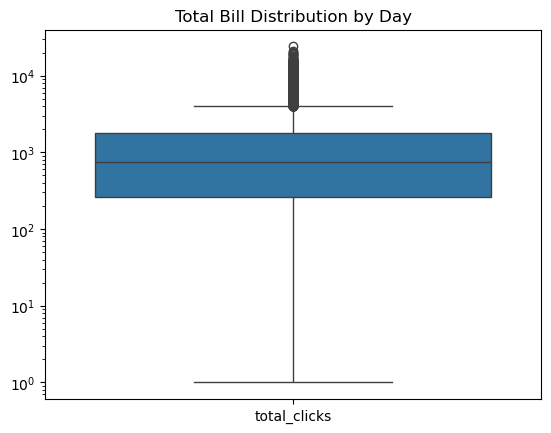

In [16]:
ax = sns.boxplot(data=total_clicks)
ax.set_yscale("log")
# Display the plot
plt.title("Total Bill Distribution by Day")
plt.show()

In [17]:
e2 = e1.groupby(["id_student","code_module","code_presentation", "activity_type"])["sum_click"].sum().unstack(fill_value=0).reset_index()

In [18]:
e2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_student         29228 non-null  int64 
 1   code_module        29228 non-null  object
 2   code_presentation  29228 non-null  object
 3   dataplus           29228 non-null  int64 
 4   dualpane           29228 non-null  int64 
 5   externalquiz       29228 non-null  int64 
 6   folder             29228 non-null  int64 
 7   forumng            29228 non-null  int64 
 8   glossary           29228 non-null  int64 
 9   homepage           29228 non-null  int64 
 10  htmlactivity       29228 non-null  int64 
 11  oucollaborate      29228 non-null  int64 
 12  oucontent          29228 non-null  int64 
 13  ouelluminate       29228 non-null  int64 
 14  ouwiki             29228 non-null  int64 
 15  page               29228 non-null  int64 
 16  questionnaire      29228 non-null  int64

In [19]:
e3 = e2.merge(total_clicks,on=["id_student","code_module","code_presentation"],how="left")

In [20]:
e3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_student         29228 non-null  int64 
 1   code_module        29228 non-null  object
 2   code_presentation  29228 non-null  object
 3   dataplus           29228 non-null  int64 
 4   dualpane           29228 non-null  int64 
 5   externalquiz       29228 non-null  int64 
 6   folder             29228 non-null  int64 
 7   forumng            29228 non-null  int64 
 8   glossary           29228 non-null  int64 
 9   homepage           29228 non-null  int64 
 10  htmlactivity       29228 non-null  int64 
 11  oucollaborate      29228 non-null  int64 
 12  oucontent          29228 non-null  int64 
 13  ouelluminate       29228 non-null  int64 
 14  ouwiki             29228 non-null  int64 
 15  page               29228 non-null  int64 
 16  questionnaire      29228 non-null  int64

In [21]:
activity_cols = e3.columns.difference(["id_student", "total_clicks","code_module","code_presentation"])



In [22]:
e3[activity_cols] = e3[activity_cols].div(
    e3["total_clicks"], axis=0
)

In [23]:
e3[e3["total_clicks"]>1]

,id_student,code_module,code_presentation,dataplus,dualpane,externalquiz,folder,forumng,glossary,homepage,...,ouwiki,page,questionnaire,quiz,repeatactivity,resource,sharedsubpage,subpage,url,total_clicks
0,6516,AAA,2014J,0.007524,0.000000,0.000000,0.0,0.161591,0.0,0.178072,...,0.000000,0.0,0.0,0.000000,0.0,0.011107,0.0,0.051236,0.051236,2791
1,8462,DDD,2013J,0.000000,0.000000,0.018576,0.0,0.055728,0.0,0.284830,...,0.027864,0.0,0.0,0.000000,0.0,0.108359,0.0,0.351393,0.035604,646
2,8462,DDD,2014J,0.000000,0.000000,0.000000,0.0,0.200000,0.0,0.700000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,10
3,11391,AAA,2013J,0.000000,0.000000,0.000000,0.0,0.206638,0.0,0.147752,...,0.000000,0.0,0.0,0.000000,0.0,0.013919,0.0,0.034261,0.005353,934
4,23629,BBB,2013B,0.000000,0.000000,0.000000,0.0,0.540373,0.0,0.223602,...,0.000000,0.0,0.0,0.192547,0.0,0.012422,0.0,0.031056,0.000000,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29223,2698257,AAA,2013J,0.000000,0.000000,0.000000,0.0,0.265172,0.0,0.217678,...,0.000000,0.0,0.0,0.000000,0.0,0.015831,0.0,0.058047,0.006596,758
29224,2698535,CCC,2014B,0.000000,0.000000,0.000000,0.0,0.393130,0.0,0.124682,...,0.000000,0.0,0.0,0.371501,0.0,0.029262,0.0,0.066158,0.007634,786
29225,2698535,EEE,2013J,0.000000,0.000579,0.000000,0.0,0.565268,0.0,0.113169,...,0.034443,0.0,0.0,0.032127,0.0,0.000868,0.0,0.003763,0.026049,3455
29226,2698577,BBB,2014J,0.000000,0.000000,0.000000,0.0,0.143654,0.0,0.284519,...,0.000000,0.0,0.0,0.100418,0.0,0.052999,0.0,0.052999,0.005579,717


In [24]:
e3.to_csv("partialratios.csv")